# 3.2
Для мероприятий с номерами 3 и 17 выполнить:

Наглядное распределение кол-ва регистраций по дням до мероприятия

Для мероприятия под номером 3:

Импортируем библиотеки

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Загружаем данные

In [26]:
file_path = "Case.xlsx"
registrations = pd.read_excel(file_path, sheet_name="registrations")
visits = pd.read_excel(file_path, sheet_name="visits")
events = pd.read_excel(file_path, sheet_name="events")

Основной код с вычислением кол-ва дней до мероприятия, группировкой данных

In [21]:
# удаляем дубликаты в visits по RegistrationID
visits = visits.drop_duplicates(subset='RegistrationID')

# соединяем таблицы registrations и visits по RegistrationID
merged = pd.merge(registrations, visits, on="RegistrationID", how="left")

# создаём столбец 'Visited' (1 если был визит, 0 если не был)
merged['Visited'] = merged['VisitID'].notnull().astype(int)

# соединяем с таблицей events, используя EventID (в merged) и ExhibitionID (в events)
merged = pd.merge(merged, events, left_on="EventID", right_on="ExhibitionID", how="left")

# преобразуем строки с датами в формат datetime
merged['Created'] = pd.to_datetime(merged['Created'], errors='coerce')
merged['EventDate'] = pd.to_datetime(merged['EventDate'], format='%d.%m.%Y', errors='coerce')

# удаляем строки, где регистрация была после проведения мероприятия
merged = merged[merged['Created'] <= merged['EventDate']]

# удаляем строки, где регистрация была более чем за 5 недель до мероприятия
five_weeks = pd.Timedelta(weeks=5)
merged = merged[merged['Created'] >= merged['EventDate'] - five_weeks]

# печатаем результат, чтобы проверить, что фильтрация выполнена корректно
print(merged.head())

# фильтруем данные по EventID
merged = merged[merged['EventID'] == 3]

# указываем дату мероприятия
event_date = pd.to_datetime('01.10.2018', format='%d.%m.%Y')

# вычисляем количество дней до мероприятия
merged['DaysBeforeEvent'] = (event_date - merged['Created']).dt.days

# группируем данные по дням до мероприятия и считаем количество регистраций
registrations_by_day = merged.groupby('DaysBeforeEvent').agg({'RegistrationID': 'count'}).reset_index()

     RegistrationID  EventID       Who  Class             Created utm_source  \
36            79069        3    Ученик   11.0 2018-09-27 20:17:22        NaN   
37           100705       17    Ученик    9.0 2019-01-17 13:14:31        NaN   
54        100034666       17    Ученик   10.0 2019-01-26 11:59:57        NaN   
270           89543       17  Родитель    9.0 2019-01-05 17:26:17        NaN   
271           90876       17  Родитель   10.0 2019-01-08 12:25:03        NaN   

    utm_medium  VisitID  Visited  ExhibitionID  EventDate  
36         NaN      NaN        0             3 2018-10-01  
37         NaN      NaN        0            17 2019-02-03  
54         NaN  42956.0        1            17 2019-02-03  
270        NaN  39197.0        1            17 2019-02-03  
271        NaN  39717.0        1            17 2019-02-03  


Построение графика

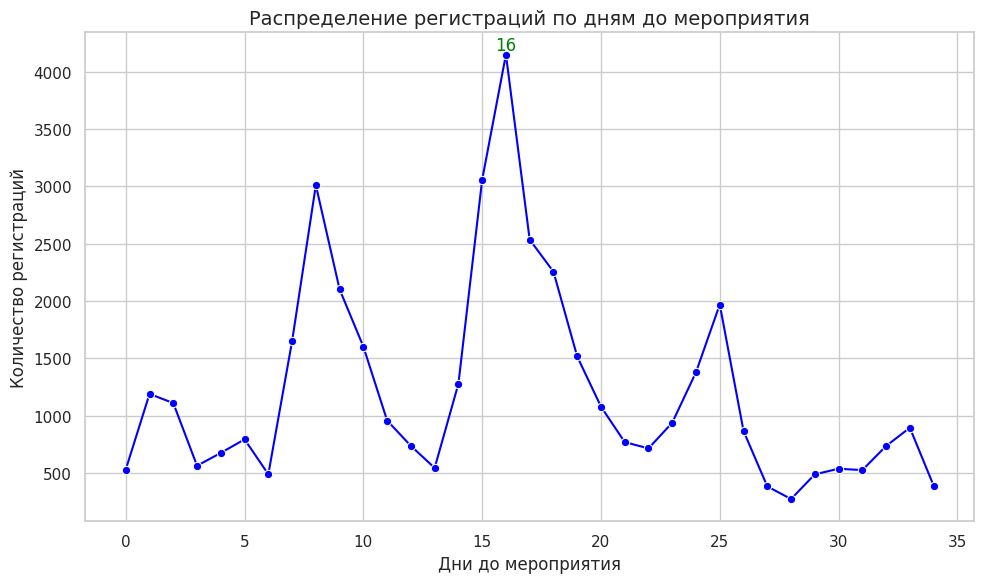

In [24]:
# настройки графика
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# строим график
sns.lineplot(x='DaysBeforeEvent', y='RegistrationID', data=registrations_by_day, marker='o', color='blue')

# находим день с максимальным количеством регистраций
max_registrations_day = registrations_by_day.loc[registrations_by_day['RegistrationID'].idxmax()]

# подписываем на графике день с максимальными регистрациями
plt.text(max_registrations_day['DaysBeforeEvent'], max_registrations_day['RegistrationID'] + 1,
         f'{max_registrations_day["DaysBeforeEvent"]}', color='green', ha='center', va='bottom', fontsize=12)

# настройки заголовков и подписей
plt.title('Распределение регистраций по дням до мероприятия', fontsize=14)
plt.xlabel('Дни до мероприятия', fontsize=12)
plt.ylabel('Количество регистраций', fontsize=12)

# плотно вмещаем элементы на графике
plt.tight_layout()
plt.show()


В условии кейса указано, что регистрация начиналась за месяц до мероприятия, поэтому регистрации, которые были сделаны ранее мы не учитывали.

Максимальное кол-во регистраций было совершено за 16 дней до начала мероприятия и было чуть более 4000 шт. Это может быть связано с успешной рекламной кампанией в тот день, с праздником/выходным в момент регистрации, с успешной работой сайта в этот же день и т.д.

Для мероприятия под номером 17:

Импортируем библиотеки

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Загружаем данные

In [ ]:
file_path = "Case.xlsx"
registrations = pd.read_excel(file_path, sheet_name="registrations")
visits = pd.read_excel(file_path, sheet_name="visits")
events = pd.read_excel(file_path, sheet_name="events")

Основной код с вычислением кол-ва дней до мероприятия, группировкой данных

In [29]:
# удаляем дубликаты в visits по RegistrationID
visits = visits.drop_duplicates(subset='RegistrationID')

# соединяем таблицы registrations и visits по RegistrationID
merged = pd.merge(registrations, visits, on="RegistrationID", how="left")

# создаём столбец 'Visited' (1 если был визит, 0 если не был)
merged['Visited'] = merged['VisitID'].notnull().astype(int)

# соединяем с таблицей events, используя EventID (в merged) и ExhibitionID (в events)
merged = pd.merge(merged, events, left_on="EventID", right_on="ExhibitionID", how="left")

# преобразуем строки с датами в формат datetime
merged['Created'] = pd.to_datetime(merged['Created'], errors='coerce')
merged['EventDate'] = pd.to_datetime(merged['EventDate'], format='%d.%m.%Y', errors='coerce')

# удаляем строки, где регистрация была после проведения мероприятия
merged = merged[merged['Created'] <= merged['EventDate']]

# удаляем строки, где регистрация была более чем за 5 недель до мероприятия
five_weeks = pd.Timedelta(weeks=5)
merged = merged[merged['Created'] >= merged['EventDate'] - five_weeks]

# печатаем результат, чтобы проверить, что фильтрация выполнена корректно
print(merged.head())

# фильтруем данные по EventID
merged = merged[merged['EventID'] == 17]

# указываем дату мероприятия
event_date = pd.to_datetime('03.02.2019', format='%d.%m.%Y')

# вычисляем количество дней до мероприятия
merged['DaysBeforeEvent'] = (event_date - merged['Created']).dt.days

# группируем данные по дням до мероприятия и считаем количество регистраций
registrations_by_day = merged.groupby('DaysBeforeEvent').agg({'RegistrationID': 'count'}).reset_index()

     RegistrationID  EventID       Who  Class             Created utm_source  \
36            79069        3    Ученик   11.0 2018-09-27 20:17:22        NaN   
37           100705       17    Ученик    9.0 2019-01-17 13:14:31        NaN   
54        100034666       17    Ученик   10.0 2019-01-26 11:59:57        NaN   
270           89543       17  Родитель    9.0 2019-01-05 17:26:17        NaN   
271           90876       17  Родитель   10.0 2019-01-08 12:25:03        NaN   

    utm_medium  VisitID  Visited  ExhibitionID  EventDate  
36         NaN      NaN        0             3 2018-10-01  
37         NaN      NaN        0            17 2019-02-03  
54         NaN  42956.0        1            17 2019-02-03  
270        NaN  39197.0        1            17 2019-02-03  
271        NaN  39717.0        1            17 2019-02-03  


Построение графика

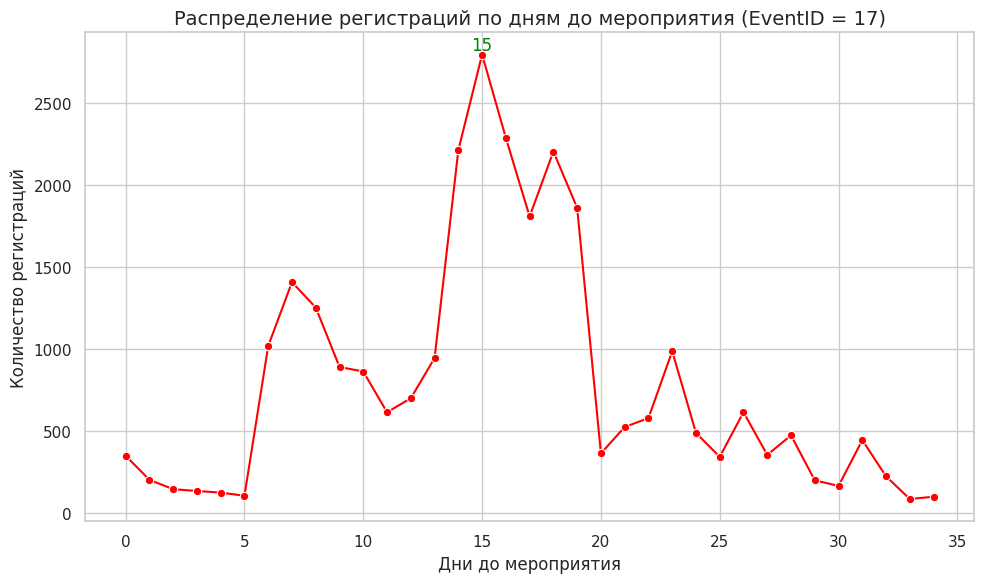

In [30]:
# настройки графика
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# строим график
sns.lineplot(x='DaysBeforeEvent', y='RegistrationID', data=registrations_by_day, marker='o', color='red')

# находим день с максимальным количеством регистраций
max_registrations_day = registrations_by_day.loc[registrations_by_day['RegistrationID'].idxmax()]

# подписываем на графике день с максимальными регистрациями
plt.text(max_registrations_day['DaysBeforeEvent'], max_registrations_day['RegistrationID'] + 1,
         f'{max_registrations_day["DaysBeforeEvent"]}', color='green', ha='center', va='bottom', fontsize=12)

# настройки заголовков и подписей
plt.title('Распределение регистраций по дням до мероприятия (EventID = 17)', fontsize=14)
plt.xlabel('Дни до мероприятия', fontsize=12)
plt.ylabel('Количество регистраций', fontsize=12)

# плотно вмещаем элементы на графике
plt.tight_layout()
plt.show()

В случае с мероприятием под номером 17 зарегистрированных пользователей оказалось все равно меньше, чем на мероприятии номер 3. Это свидетельствует о большей востребованности или большем финансировании мероприятия 3.

Максимальное кол-во регистраций было совершено за 15 дней до начала мероприятия и было примерно 2800 шт. Что интересно, примерно за столько же дней, за сколько и у мероприятия под номером 3. Это может означать схожесть рекламной стратегии для этих двух мероприятий.


# 5
Взять все мероприятия и сделать попарный анализ показателя доходимости. Можно ли сказать, что разница в показателе доходимости статистичеки значимая? (взять уровень значимости 0,01). Использование какого критерия поможет в этом упражнении?

Импортируем библиотеки

In [8]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

Загружаем данные

In [7]:
file_path = "Case.xlsx"
registrations = pd.read_excel(file_path, sheet_name="registrations")
visits = pd.read_excel(file_path, sheet_name="visits")
events = pd.read_excel(file_path, sheet_name="events")

Подготавливаем данные: удаляем дубликаты посещений, если человек зарегистрировался после мероприятия удаляем эти данные, если человек зарегистрировался более чем за 5 недель удаляем эти данные, делаем сводную таблицу

In [14]:
# удаляем дубликаты в visits по RegistrationID
visits = visits.drop_duplicates(subset='RegistrationID')

# соединяем таблицы registrations и visits по RegistrationID
merged = pd.merge(registrations, visits, on="RegistrationID", how="left")

# создаём столбец 'Visited' (1 если был визит, 0 если не был)
merged['Visited'] = merged['VisitID'].notnull().astype(int)

# соединяем с таблицей events, используя EventID (в merged) и ExhibitionID (в events)
merged = pd.merge(merged, events, left_on="EventID", right_on="ExhibitionID", how="left")

# преобразуем строки с датами в формат datetime
merged['Created'] = pd.to_datetime(merged['Created'], errors='coerce')
merged['EventDate'] = pd.to_datetime(merged['EventDate'], format='%d.%m.%Y', errors='coerce')

# удаляем строки, где регистрация была после проведения мероприятия
merged = merged[merged['Created'] <= merged['EventDate']]

# удаляем строки, где регистрация была более чем за 5 недель до мероприятия
five_weeks = pd.Timedelta(weeks=5)
merged = merged[merged['Created'] >= merged['EventDate'] - five_weeks]

# печатаем результат, чтобы проверить, что фильтрация выполнена корректно
print(merged.head())


     RegistrationID  EventID       Who  Class             Created utm_source  \
36            79069        3    Ученик   11.0 2018-09-27 20:17:22        NaN   
37           100705       17    Ученик    9.0 2019-01-17 13:14:31        NaN   
54        100034666       17    Ученик   10.0 2019-01-26 11:59:57        NaN   
270           89543       17  Родитель    9.0 2019-01-05 17:26:17        NaN   
271           90876       17  Родитель   10.0 2019-01-08 12:25:03        NaN   

    utm_medium  VisitID  Visited  ExhibitionID  EventDate  
36         NaN      NaN        0             3 2018-10-01  
37         NaN      NaN        0            17 2019-02-03  
54         NaN  42956.0        1            17 2019-02-03  
270        NaN  39197.0        1            17 2019-02-03  
271        NaN  39717.0        1            17 2019-02-03  


Далее идет основной код.

Его суть:
Сначала проводим попарный анализ доходимости мероприятий.

В качестве критерия испольуем Хи-квадрат с уровнем значимости = 0,01. Если уровень значимости < 0,01, то результат статистического теста является статистически значимым, в противном случае статистически не значимым.

Далее применяем поправку на множественные сравнения по методу Холма-Бонферрони.

*Краткая справка по методу:*

* Сначала ранжируем p-значения: все p-значения от полученных тестов сортируются в порядке возрастания.
* Далее пересчитываем p-значения: для p-значения с рангом i (где i — это порядковый номер после сортировки) порог вычисляется как α/n-i+1​, где:

α — выбранный уровень значимости (0.01)

n — общее количество тестов.
* Отклонение гипотезы: Если скорректированное p-значение меньше порога, гипотеза отклоняется.

В итоге получим 10 попарных исследований с поправкой на множественное исследование. Финальный вывод делаем так: если количество статистически значимых сравнений после поправки < 50%? то разница в показателях доходимости не статистически значима. В противном случае статистически значима.

Почему 50%?

50% — это условный порог, который может быть использован в случае, если все тесты одинаково важны и если каждый тест имеет одинаковую вероятность ошибки. Это довольно консервативный подход, который позволяет снизить вероятность ложноположительных выводов.

In [12]:
# группируем по EventID, считаем количество регистраций и посещений
event_analysis = merged.groupby('EventID').agg(
    registrations_count=('RegistrationID', 'count'),
    visits_count=('Visited', 'sum')
).reset_index()

# рассчитываем показатели доходимости (отношение посещений к регистрациям)
event_analysis['attendance_rate'] = event_analysis['visits_count'] / event_analysis['registrations_count']

# выводим результаты по каждому событию
print("Показатели доходимости для каждого события:")
print(event_analysis)

# список EventID для попарного анализа
event_ids = [3, 15, 17, 18, 20]

# словарь для хранения значений хи-квадрат и p-value
chi2_values = []
p_values = []
comparisons = []

# перебираем все пары EventID для попарного анализа
for i in range(len(event_ids)):
    for j in range(i + 1, len(event_ids)):
        event_i = event_ids[i]
        event_j = event_ids[j]

        # получаем данные для текущей пары событий
        event_i_data = event_analysis[event_analysis['EventID'] == event_i]
        event_j_data = event_analysis[event_analysis['EventID'] == event_j]

        # формируем таблицу наблюдений для хи-квадрат (посещения и не посещения)
        observed = np.array([
            [event_i_data['visits_count'].values[0], event_i_data['registrations_count'].values[0] - event_i_data['visits_count'].values[0]],
            [event_j_data['visits_count'].values[0], event_j_data['registrations_count'].values[0] - event_j_data['visits_count'].values[0]]
        ])

        # применяем критерий хи-квадрат для проверки статистической значимости
        chi2, p_value, dof, expected = stats.chi2_contingency(observed)

        # добавляем результаты в списки
        chi2_values.append(chi2)
        p_values.append(p_value)
        comparisons.append(f'{event_i} vs {event_j}')

        # выводим результаты теста для каждой пары
        print(f"\nСравнение событий {event_i} и {event_j}:")
        print(f"p-value до поправки: {p_value}")

# применяем поправку на множественные сравнения по методу Холма-Бонферрони с помощью multipletests
corrected_results = multipletests(p_values, method='holm', alpha=0.01)

# подсчитываем количество статистически значимых результатов после поправки
significant_results = sum(corrected_results[0])

# выводим итоговый ответ с новыми p-значениями
print("\nРезультаты после поправки на множественные сравнения:")
for i, comparison in enumerate(comparisons):
    print(f"{comparison}: p-value после поправки: {corrected_results[1][i]}")

print(f"\nКоличество статистически значимых сравнений после поправки: {significant_results} из {len(p_values)}")

if significant_results > len(p_values) / 2:  # Например, более 50% сравнений
    print("В целом разница в показателях доходимости статистически значима!")
else:
    print("В целом разница в показателях доходимости не статистически значима.")

Показатели доходимости для каждого события:
   EventID  registrations_count  visits_count  attendance_rate
0        3                42728         16879         0.395034
1       15                 3705           823         0.222132
2       17                27913         12326         0.441586
3       18                 4139          1002         0.242087
4       20                10965          2905         0.264934

Сравнение событий 3 и 15:
p-value до поправки: 8.324079558371397e-96

Сравнение событий 3 и 17:
p-value до поправки: 1.2265973445474313e-34

Сравнение событий 3 и 18:
p-value до поправки: 3.33728780452176e-83

Сравнение событий 3 и 20:
p-value до поправки: 6.307813612825172e-140

Сравнение событий 15 и 17:
p-value до поправки: 7.609057505412296e-143

Сравнение событий 15 и 18:
p-value до поправки: 0.039260876173390705

Сравнение событий 15 и 20:
p-value до поправки: 2.581193611398065e-07

Сравнение событий 17 и 18:
p-value до поправки: 2.8352575539189365e-130

Сравнение 

Получаем, что в целом разница в показателях доходимости статистически значима.

Иными словами:

* Скорее всего существует реальная разница в том, как участники посещают мероприятия, что может указывать на различия в привлекательности, содержании, уровне интереса или других факторах.
* Например, одно из мероприятий могло иметь более высокую посещаемость по сравнению с другими, и это не является случайным.


Теперь для наглядности визуализируем данные.

Получим два графика: количество регистраций и посещений для каждого события и значение Хи-квадрат для всех пар мероприятий

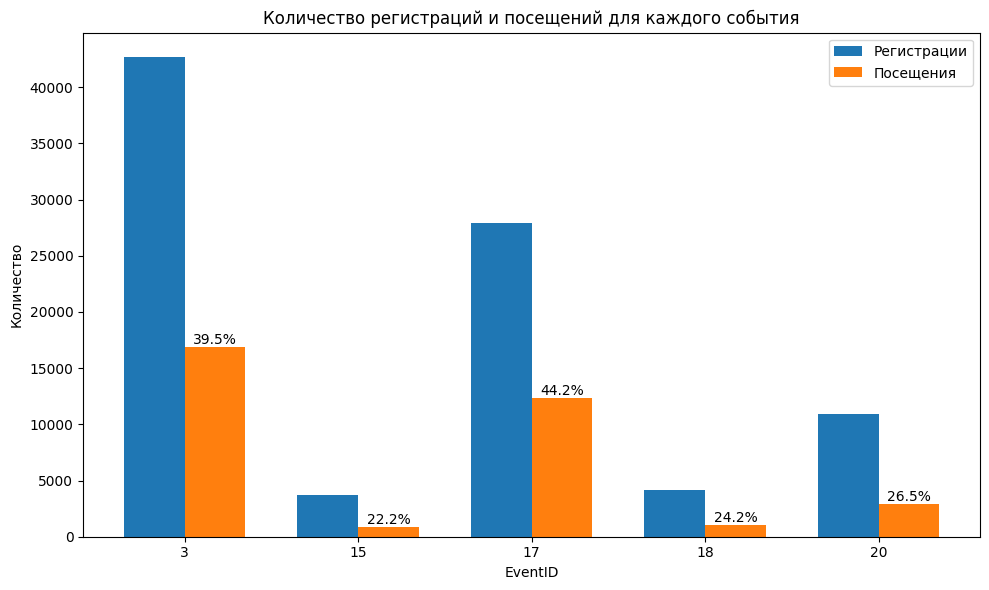

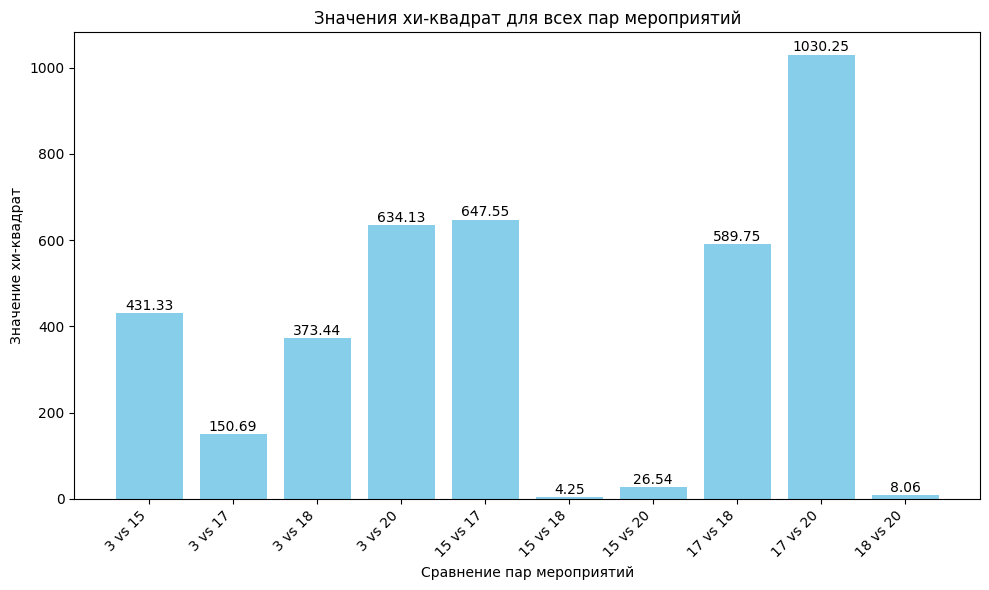

In [13]:
# график 1: Количество регистраций и посещений для каждого события
fig, ax = plt.subplots(figsize=(10, 6))

# индексы для x-оси
x = np.arange(len(event_analysis))

# ширина баров
bar_width = 0.35

# построение столбцов
bars_registrations = ax.bar(x - bar_width / 2, event_analysis['registrations_count'], bar_width, label='Регистрации')
bars_visits = ax.bar(x + bar_width / 2, event_analysis['visits_count'], bar_width, label='Посещения')

# добавляем подписи
ax.set_xlabel('EventID')
ax.set_ylabel('Количество')
ax.set_title('Количество регистраций и посещений для каждого события')
ax.set_xticks(x)
ax.set_xticklabels(event_analysis['EventID'])
ax.legend()

# добавляем текст на столбцы с количеством посещений
for i, bar in enumerate(bars_visits):
    yval = bar.get_height()
    total_registrations = event_analysis['registrations_count'].iloc[i]
    percentage = (yval / total_registrations) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 5, f'{percentage:.1f}%', ha='center', va='bottom')

# показываем диаграмму
plt.tight_layout()
plt.show()

# график 2: Хи-квадрат для всех пар мероприятий
fig, ax = plt.subplots(figsize=(10, 6))

# индексы для x-оси
x = np.arange(len(comparisons))

# строим бар-график для хи-квадрат
bars = ax.bar(x, chi2_values, color='skyblue')

# добавляем подписи и заголовки
ax.set_xlabel('Сравнение пар мероприятий')
ax.set_ylabel('Значение хи-квадрат')
ax.set_title('Значения хи-квадрат для всех пар мероприятий')
ax.set_xticks(x)
ax.set_xticklabels(comparisons, rotation=45, ha="right")

# добавляем текст с хи-квадрат над столбцами
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom')

# показываем диаграмму
plt.tight_layout()
plt.show()

Из первого графика можем вывести, что процент визитов от регистраций не превышает 45%. Самое популярное мероприятие под номером 3, а самое невостребованное под номером 15.

По второму графику: если значение хи-квадрат высокое, это означает, что разница в показателях доходимости для двух событий значительно отличается. Таким образом, скорее всего, нулевая гипотеза, предполагающая отсутствие различий, будет отклонена, и можно сказать, что разница в доходимости статистически значима.
Самая большая разница между событиями 17 и 20, а самая маленькая между событиями 15 и 18.

# 6
Сделать аналогичное п.5 упражнение, но взять только регистрации "Родителей", как более значимых участия в контексте коммерциализации

Импортируем библиотеки

In [ ]:
import pandas as pd
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests

Загружаем данные

In [ ]:
file_path = "Case.xlsx"
registrations = pd.read_excel(file_path, sheet_name="registrations")
visits = pd.read_excel(file_path, sheet_name="visits")
events = pd.read_excel(file_path, sheet_name="events")

Подготавливаем данные: удаляем дубликаты посещений, данные без указания класса, делаем сводную таблицу

In [15]:
# фильтруем только регистрации "Родителей"
registrations = registrations[registrations['Who'] == 'Родитель']

# удаляем дубликаты в visits по RegistrationID
visits = visits.drop_duplicates(subset='RegistrationID')

# соединяем таблицы registrations и visits по RegistrationID
merged = pd.merge(registrations, visits, on="RegistrationID", how="left")

# создаём столбец 'Visited' (1 если был визит, 0 если не был)
merged['Visited'] = merged['VisitID'].notnull().astype(int)

# соединяем с таблицей events, используя EventID (в merged) и ExhibitionID (в events)
merged = pd.merge(merged, events, left_on="EventID", right_on="ExhibitionID", how="left")

# преобразуем строки с датами в формат datetime
merged['Created'] = pd.to_datetime(merged['Created'], errors='coerce')
merged['EventDate'] = pd.to_datetime(merged['EventDate'], format='%d.%m.%Y', errors='coerce')

# удаляем строки, где регистрация была после проведения мероприятия
merged = merged[merged['Created'] <= merged['EventDate']]

# удаляем строки, где регистрация была более чем за 5 недель до мероприятия
five_weeks = pd.Timedelta(weeks=5)
merged = merged[merged['Created'] >= merged['EventDate'] - five_weeks]

# печатаем результат, чтобы проверить, что фильтрация выполнена корректно
print(merged.head())

    RegistrationID  EventID       Who  Class             Created utm_source  \
95           89543       17  Родитель    9.0 2019-01-05 17:26:17        NaN   
96           90876       17  Родитель   10.0 2019-01-08 12:25:03        NaN   
97           90900       17  Родитель   10.0 2019-01-08 13:57:31        NaN   
98           91918       17  Родитель   11.0 2019-01-10 15:01:44        NaN   
99           92640       17  Родитель   11.0 2019-01-11 09:23:24        NaN   

   utm_medium  VisitID  Visited  ExhibitionID  EventDate  
95        NaN  39197.0        1            17 2019-02-03  
96        NaN  39717.0        1            17 2019-02-03  
97        NaN      NaN        0            17 2019-02-03  
98        NaN      NaN        0            17 2019-02-03  
99        NaN      NaN        0            17 2019-02-03  


Далее идет основной код, идея точно такая же, как и в предыдущем пункте, но здесь учитываем только регистрации родителей, как более значимых участников в контексте коммерциализации

In [16]:
# группируем по EventID, считаем количество регистраций и посещений
event_analysis = merged.groupby('EventID').agg(
    registrations_count=('RegistrationID', 'count'),
    visits_count=('Visited', 'sum')
).reset_index()

# рассчитываем показатели доходимости (отношение посещений к регистрациям)
event_analysis['attendance_rate'] = event_analysis['visits_count'] / event_analysis['registrations_count']

# выводим результаты по каждому событию
print("Показатели доходимости для каждого события:")
print(event_analysis)

# список EventID для попарного анализа
event_ids = [3, 15, 17, 18, 20]

# словарь для хранения значений хи-квадрат и p-value
chi2_values = []
p_values = []
comparisons = []

# перебираем все пары EventID для попарного анализа
for i in range(len(event_ids)):
    for j in range(i + 1, len(event_ids)):
        event_i = event_ids[i]
        event_j = event_ids[j]

        # получаем данные для текущей пары событий
        event_i_data = event_analysis[event_analysis['EventID'] == event_i]
        event_j_data = event_analysis[event_analysis['EventID'] == event_j]

        # формируем таблицу наблюдений для хи-квадрат (посещения и не посещения)
        observed = np.array([
            [event_i_data['visits_count'].values[0], event_i_data['registrations_count'].values[0] - event_i_data['visits_count'].values[0]],
            [event_j_data['visits_count'].values[0], event_j_data['registrations_count'].values[0] - event_j_data['visits_count'].values[0]]
        ])

        # применяем критерий хи-квадрат для проверки статистической значимости
        chi2, p_value, dof, expected = stats.chi2_contingency(observed)

        # добавляем результаты в списки
        chi2_values.append(chi2)
        p_values.append(p_value)
        comparisons.append(f'{event_i} vs {event_j}')

        # выводим результаты теста для каждой пары
        print(f"\nСравнение событий {event_i} и {event_j}:")
        print(f"p-value до поправки: {p_value}")

# применяем поправку на множественные сравнения по методу Холма-Бонферрони с помощью multipletests
corrected_results = multipletests(p_values, method='holm', alpha=0.01)

# подсчитываем количество статистически значимых результатов после поправки
significant_results = sum(corrected_results[0])

# выводим итоговый ответ с новыми p-значениями
print("\nРезультаты после поправки на множественные сравнения:")
for i, comparison in enumerate(comparisons):
    print(f"{comparison}: p-value после поправки: {corrected_results[1][i]}")

print(f"\nКоличество статистически значимых сравнений после поправки: {significant_results} из {len(p_values)}")

if significant_results > len(p_values) / 2:  # Например, более 50% сравнений
    print("В целом разница в показателях доходимости статистически значима!")
else:
    print("В целом разница в показателях доходимости не статистически значима.")

Показатели доходимости для каждого события:
   EventID  registrations_count  visits_count  attendance_rate
0        3                12734          5009         0.393356
1       15                 1573           344         0.218690
2       17                10151          4165         0.410304
3       18                 1759           434         0.246731
4       20                 4656          1204         0.258591

Сравнение событий 3 и 15:
p-value до поправки: 2.1004631416085047e-41

Сравнение событий 3 и 17:
p-value до поправки: 0.009723978875902038

Сравнение событий 3 и 18:
p-value до поправки: 1.5617715558669358e-32

Сравнение событий 3 и 20:
p-value до поправки: 1.8119361856039123e-60

Сравнение событий 15 и 17:
p-value до поправки: 1.0859769512551917e-47

Сравнение событий 15 и 18:
p-value до поправки: 0.061621695703986096

Сравнение событий 15 и 20:
p-value до поправки: 0.0017349138737798257

Сравнение событий 17 и 18:
p-value до поправки: 1.5432910030129152e-38

Сравнение 

Получаем, что в целом разница в показателях доходимости статистически значима.

Иными словами:

* Скорее всего существует реальная разница в том, как участники посещают мероприятия, что может указывать на различия в привлекательности, содержании, уровне интереса или других факторах.
* Например, одно из мероприятий могло иметь более высокую посещаемость по сравнению с другими, и это не является случайным.


Теперь для наглядности визуализируем данные.

Получим два графика: количество регистраций и посещений родителей для каждого события и значение Хи-квадрат для всех пар мероприятий


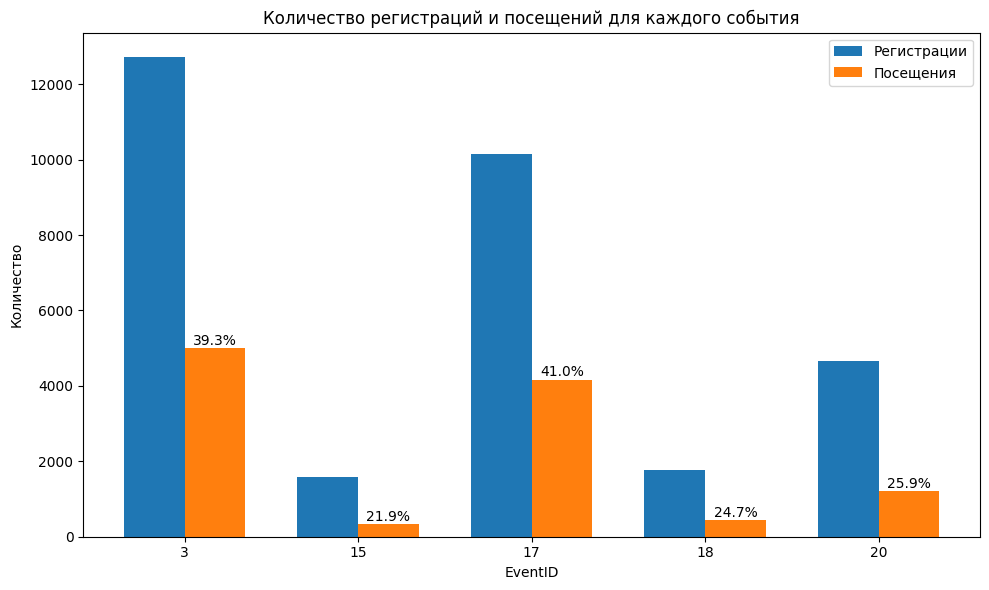

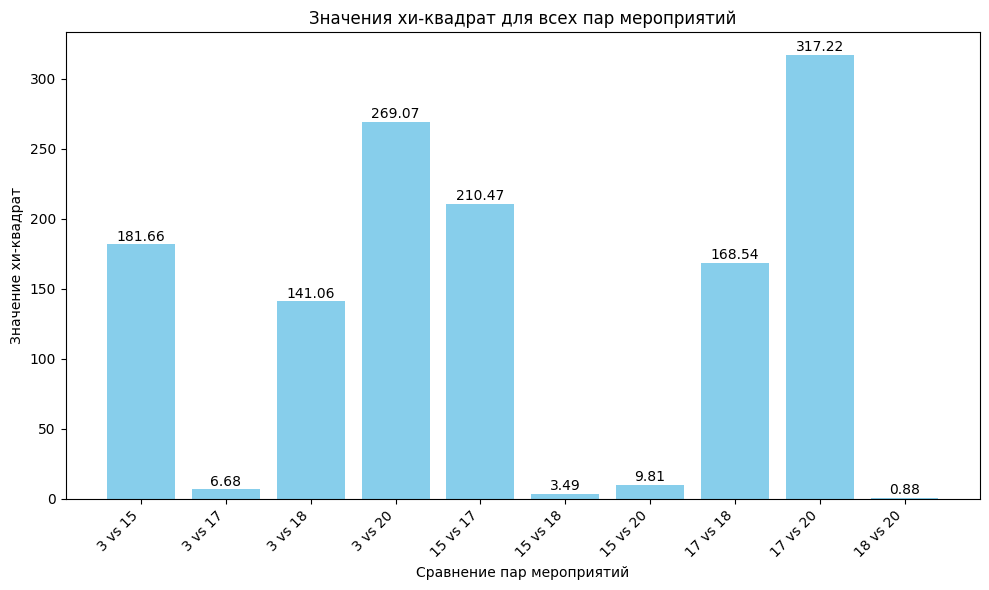

In [18]:
# график 1: Количество регистраций и посещений для каждого события
fig, ax = plt.subplots(figsize=(10, 6))

# индексы для x-оси
x = np.arange(len(event_analysis))

# ширина баров
bar_width = 0.35

# построение столбцов
bars_registrations = ax.bar(x - bar_width / 2, event_analysis['registrations_count'], bar_width, label='Регистрации')
bars_visits = ax.bar(x + bar_width / 2, event_analysis['visits_count'], bar_width, label='Посещения')

# добавляем подписи
ax.set_xlabel('EventID')
ax.set_ylabel('Количество')
ax.set_title('Количество регистраций и посещений для каждого события')
ax.set_xticks(x)
ax.set_xticklabels(event_analysis['EventID'])
ax.legend()

# добавляем текст на столбцы с количеством посещений
for i, bar in enumerate(bars_visits):
    yval = bar.get_height()
    total_registrations = event_analysis['registrations_count'].iloc[i]
    percentage = (yval / total_registrations) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 5, f'{percentage:.1f}%', ha='center', va='bottom')

# показываем диаграмму
plt.tight_layout()
plt.show()

# график 2: Хи-квадрат для всех пар мероприятий
fig, ax = plt.subplots(figsize=(10, 6))

# индексы для x-оси
x = np.arange(len(comparisons))

# строим бар-график для хи-квадрат
bars = ax.bar(x, chi2_values, color='skyblue')

# добавляем подписи и заголовки
ax.set_xlabel('Сравнение пар мероприятий')
ax.set_ylabel('Значение хи-квадрат')
ax.set_title('Значения хи-квадрат для всех пар мероприятий')
ax.set_xticks(x)
ax.set_xticklabels(comparisons, rotation=45, ha="right")

# добавляем текст с хи-квадрат над столбцами
for i, bar in enumerate(bars):
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, f'{yval:.2f}', ha='center', va='bottom')

# показываем диаграмму
plt.tight_layout()
plt.show()

Из первого графика можем вывести, что процент визитов от регистраций (для родителей) не превышает 41%. Самое популярное мероприятие под номером 3, а самое невостребованное под номером 15.

По второму графику: если значение хи-квадрат высокое, это означает, что разница в показателях доходимости для двух событий значительно отличается. Таким образом, скорее всего, нулевая гипотеза, предполагающая отсутствие различий, будет отклонена, и можно сказать, что разница в доходимости статистически значима.
Самая большая разница между событиями 17 и 20, а самая маленькая между событиями 18 и 20.